# Predictive Maintenance (PdM) for Industrial Centrifugal Pumps

**End-to-end ML pipeline**: EDA -> Preprocessing -> Feature Engineering -> Feature
Selection -> Classification (failure severity) -> Regression (remaining useful
life) -> Model Comparison.

Reusable logic lives in [`pdm_utils.py`](./pdm_utils.py) (data loading,
preprocessing, feature engineering, evaluation) and is imported here so the
notebook stays focused on *narrative + results* while the functions themselves
are unit-testable and reusable outside the notebook (e.g. from a future
training script or API).

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, RFE
from sklearn.metrics import recall_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

import pdm_utils as u

RANDOM_STATE = u.RANDOM_STATE
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# --- Palette (validated, colorblind-safe categorical + status sets) ---
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
CAT = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"]  # blue, aqua, yellow, green, violet
STATUS = {"Normal": "#0ca30c", "Warning": "#fab219", "Critical": "#d03b3b"}  # good/warning/critical
SEQ_BLUE = "#2a78d6"
CLASS_NAMES = u.CLASS_NAMES  # Normal, Warning, Critical, Bearing_Failure, Motor_Failure, Seal_Failure
CLASS_COLORS = [STATUS["Normal"], STATUS["Warning"], STATUS["Critical"], "#e34948", "#e87ba4", "#eb6834"]

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRID,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
sns.set_style("whitegrid", {"axes.facecolor": SURFACE, "grid.color": GRID})

DATA_PATH = "data/AI_Predictive_Maintenance_Pump_Dataset_10000.xlsx"
FIG_DIR = "outputs/figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Dataset Understanding

### Business problem
Unplanned failures of industrial centrifugal pumps cause costly downtime and
emergency maintenance. Telemetry (vibration, temperature, pressure, flow) is
already logged hourly per pump. The goal is to turn that telemetry into two
decision-support signals for plant operators:

1. **Is this pump entering a warning/critical state right now?** (classification)
2. **How many hours of useful life does it have left, so spare parts and a
   maintenance window can be scheduled?** (regression)

### ML approach
Both outputs are supervised learning problems on the same engineered feature
set: a **multi-class classifier** for failure severity and a **regressor** for
remaining useful life (RUL). Tree-based ensembles (Random Forest, XGBoost,
LightGBM) are the primary candidates because the relationship between sensor
drift and failure risk is non-linear and involves feature interactions
(e.g. rising temperature *combined with* falling pressure) that trees capture
natively without manual basis-function engineering.

### Feature purpose
| Column | Type | Purpose |
|---|---|---|
| `Timestamp` | datetime | Hourly log time; used to order readings and derive time-aware features |
| `Asset_ID` | identifier | Which physical pump the reading belongs to; used to **group** rolling/lag calculations, not as a model input (see note below) |
| `Machine_Model` | categorical | Pump model/design; different designs may have different failure signatures |
| `Location` | categorical | Site/platform; potentially confounded with environmental stress |
| `Vibration_mm_s` | numerical (telemetry) | Mechanical wear indicator — bearing/seal degradation shows up as rising vibration |
| `Temperature_C` | numerical (telemetry) | Friction/lubrication health indicator |
| `Pressure_psi` | numerical (telemetry) | Flow/seal integrity indicator |
| `Flow_Rate_m3_h` | numerical (telemetry) | Throughput — drops can indicate blockage or impeller wear |
| `Failure_State` | categorical | **Classification target source** (Normal / Warning / Critical / three terminal-failure labels) |
| `RUL_Hours` | numerical | **Regression target** — hours remaining until failure |

**Data reality check** (found by profiling the actual file, not just the spec):
the dataset holds **20 pumps** sampled on an interleaved hourly log, so each
individual pump is actually only read once every 20 hours. `Machine_Model` and
`Location` change from row to row for the *same* `Asset_ID` — physically a
pump doesn't change model or site, so these two columns behave like
per-reading categorical noise rather than fixed asset attributes. We'll still
encode `Machine_Model` as a feature per the project spec, but this is worth
flagging: it caps how much genuine signal that column can contribute.

In [2]:
df_raw = u.load_raw_data(DATA_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 10,000 rows x 10 columns


,Timestamp,Asset_ID,Machine_Model,Location,Vibration_mm_s,Temperature_C,Pressure_psi,Flow_Rate_m3_h,RUL_Hours,Failure_State
0,2026-01-01 00:00:00,PUMP_001,Hydra-500,Onshore-Terminal-2,2.3,57.4,145.7,248.9,500,Normal
1,2026-01-01 01:00:00,PUMP_002,Nova-P,Onshore-Terminal-1,1.5,59.8,147.9,247.2,499,Normal
2,2026-01-01 02:00:00,PUMP_003,Nova-P,Offshore-Platform-B,2.2,60.5,145.0,252.6,498,Normal
3,2026-01-01 03:00:00,PUMP_004,Nova-P,Offshore-Platform-B,2.5,56.7,148.2,248.5,497,Normal
4,2026-01-01 04:00:00,PUMP_005,Hydra-500,Onshore-Terminal-1,2.4,66.7,140.6,254.7,496,Normal


In [3]:
print("Data types:")
print(df_raw.dtypes)
print()
numerical_cols = ["Vibration_mm_s", "Temperature_C", "Pressure_psi", "Flow_Rate_m3_h", "RUL_Hours"]
categorical_cols = ["Asset_ID", "Machine_Model", "Location", "Failure_State"]
print(f"Numerical columns:   {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")
print()
print(f"Classification target : Failure_State -> encoded as a 6-class 'Failure_Class' (see Stage 3)")
print(f"Regression target     : RUL_Hours")

Data types:
Timestamp          object
Asset_ID           object
Machine_Model      object
Location           object
Vibration_mm_s    float64
Temperature_C     float64
Pressure_psi      float64
Flow_Rate_m3_h    float64
RUL_Hours           int64
Failure_State      object
dtype: object

Numerical columns:   ['Vibration_mm_s', 'Temperature_C', 'Pressure_psi', 'Flow_Rate_m3_h', 'RUL_Hours']
Categorical columns: ['Asset_ID', 'Machine_Model', 'Location', 'Failure_State']

Classification target : Failure_State -> encoded as a 6-class 'Failure_Class' (see Stage 3)
Regression target     : RUL_Hours


In [4]:
n_assets = df_raw["Asset_ID"].nunique()
print(f"Unique pumps (Asset_ID): {n_assets}")
print(f"Readings per pump: {df_raw['Asset_ID'].value_counts().unique()}")
print(f"Timestamp range: {df_raw['Timestamp'].min()} -> {df_raw['Timestamp'].max()}")
print()
print("Failure_State value counts:")
print(df_raw["Failure_State"].value_counts())

Unique pumps (Asset_ID): 20
Readings per pump: [500]
Timestamp range: 2026-01-01 00:00:00 -> 2027-02-21 15:00:00

Failure_State value counts:
Failure_State
Normal             9000
Warning             800
Critical            180
Bearing_Failure       9
Motor_Failure         7
Seal_Failure          4
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

In [5]:
print("=== Overview ===")
df_raw.info()

=== Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       10000 non-null  object 
 1   Asset_ID        10000 non-null  object 
 2   Machine_Model   10000 non-null  object 
 3   Location        10000 non-null  object 
 4   Vibration_mm_s  10000 non-null  float64
 5   Temperature_C   10000 non-null  float64
 6   Pressure_psi    10000 non-null  float64
 7   Flow_Rate_m3_h  10000 non-null  float64
 8   RUL_Hours       10000 non-null  int64  
 9   Failure_State   10000 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 781.4+ KB


In [6]:
print("=== Missing values ===")
print(df_raw.isnull().sum())
print()
print(f"=== Duplicate rows: {df_raw.duplicated().sum()} ===")

=== Missing values ===
Timestamp         0
Asset_ID          0
Machine_Model     0
Location          0
Vibration_mm_s    0
Temperature_C     0
Pressure_psi      0
Flow_Rate_m3_h    0
RUL_Hours         0
Failure_State     0
dtype: int64

=== Duplicate rows: 0 ===


**Insight:** zero missing values and zero duplicate rows in the raw file. That's
unusual for real plant telemetry (sensors drop packets, log files get
concatenated with overlap) — this is a clean synthetic dataset. The
preprocessing stage still implements missing-value handling and dedup as
reusable functions so the pipeline is production-safe against dirtier data.

In [7]:
print("=== Summary statistics (numerical) ===")
df_raw[numerical_cols].describe().T

=== Summary statistics (numerical) ===


,count,mean,std,min,25%,50%,75%,max
Vibration_mm_s,10000.0,2.32281,1.193184,1.2,1.60,2.1,2.50,12.4
Temperature_C,10000.0,64.61187,8.231399,55.0,59.20,63.3,67.50,119.3
Pressure_psi,10000.0,143.73423,5.480398,90.6,141.70,144.4,147.20,150.0
Flow_Rate_m3_h,10000.0,248.09529,7.858274,160.0,246.60,249.4,252.20,255.0
RUL_Hours,10000.0,250.49800,144.347960,0.0,125.75,250.5,375.25,500.0


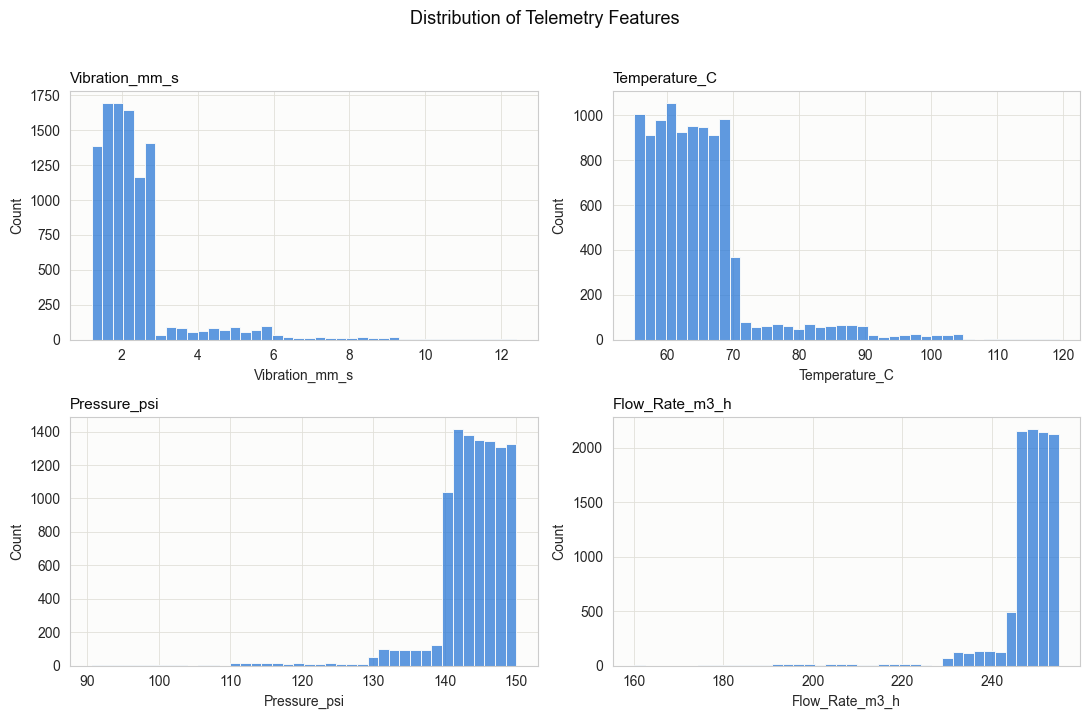

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
telemetry_cols = ["Vibration_mm_s", "Temperature_C", "Pressure_psi", "Flow_Rate_m3_h"]
for ax, col in zip(axes.flat, telemetry_cols):
    sns.histplot(df_raw[col], bins=40, color=SEQ_BLUE, edgecolor=SURFACE, ax=ax)
    ax.set_title(col, color=INK_PRIMARY, fontsize=11, loc="left")
    ax.set_ylabel("Count")
fig.suptitle("Distribution of Telemetry Features", fontsize=13, color=INK_PRIMARY, y=1.02)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_telemetry_distributions.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight:** all four telemetry channels are roughly unimodal and bell-shaped
around their normal operating point (Vibration ~2.0 mm/s, Temperature ~62 C,
Pressure ~145 psi, Flow ~250 m3/h), with a long right tail on Vibration and
Temperature — consistent with the small fraction of readings captured during
Warning/Critical degradation, where those two channels spike before failure.

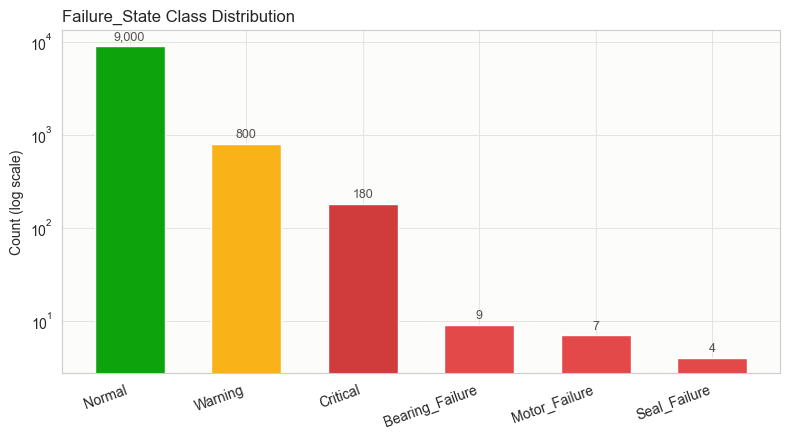

In [9]:
order = ["Normal", "Warning", "Critical", "Bearing_Failure", "Motor_Failure", "Seal_Failure"]
counts = df_raw["Failure_State"].value_counts().reindex(order)
colors = [STATUS.get(s, "#e34948") for s in order]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(order, counts.values, color=colors, width=0.6)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_title("Failure_State Class Distribution", loc="left", fontsize=12)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.15, f"{val:,}", ha="center", fontsize=9, color=INK_SECONDARY)
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_failure_state_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight:** severe class imbalance (log scale needed just to see the small
classes) — 90% Normal, 8% Warning, 1.8% Critical, and the three terminal
failure classes combined are only 0.2% of the data (20 rows total, and — as
profiled earlier — all 20 belong to a single pump). Per your call, all 6
classes are modeled directly (`Failure_Class` in Stage 3) rather than
collapsing or excluding the terminal states. Flagging up front what that
means: with 9 / 7 / 4 total rows for Bearing_Failure / Motor_Failure /
Seal_Failure, there is very little independent evidence — and it all comes
from one pump — so per-class metrics on those three specific classes should
be expected to be noisy or unstable, and are reported explicitly (not
hidden inside a macro average) in Stage 7.

In [10]:
sensor_ranges = df_raw.groupby("Failure_State")[telemetry_cols].agg(["min", "max"])
sensor_ranges = sensor_ranges.reindex(order)
sensor_ranges

Vibration_mm_s       Temperature_C        Pressure_psi        Flow_Rate_m3_h       
                           min   max           min    max          min    max            min    max
Failure_State                                                                                      
Normal                     1.2   2.8          55.0   70.0        140.0  150.0          245.0  255.0
Warning                    3.0   6.0          70.1   90.0        130.0  142.0          230.0  245.0
Critical                   6.0   9.5          90.1  105.0        110.1  130.0          190.0  224.5
Bearing_Failure            9.8  12.3         105.5  119.3         90.6  102.0          160.0  193.0
Motor_Failure             10.8  12.1         108.7  115.7         94.7  105.8          180.7  194.0
Seal_Failure              10.0  12.4         110.4  117.7         96.2  107.6          175.7  182.7

**Insight — separability differs sharply by class pair:** Normal, Warning,
and Critical sit in completely non-overlapping sensor bands (e.g. Vibration
1.2-2.8 / 3.0-6.0 / 6.0-9.5 mm/s) — trivially separable. The three terminal
failure classes are a different story: Bearing_Failure (9.8-12.3),
Motor_Failure (10.8-12.1), and Seal_Failure (10.0-12.4) all overlap heavily
with each other on Vibration, and the same pattern holds on Temperature,
Pressure, and Flow. Combined with only 4-9 samples per class, expect models
to separate {Normal, Warning, Critical} from the three failure types
cleanly, but struggle to tell Bearing_Failure / Motor_Failure / Seal_Failure
apart from **each other** — that's a data-scarcity and class-overlap
limitation, not something more feature engineering can fix.

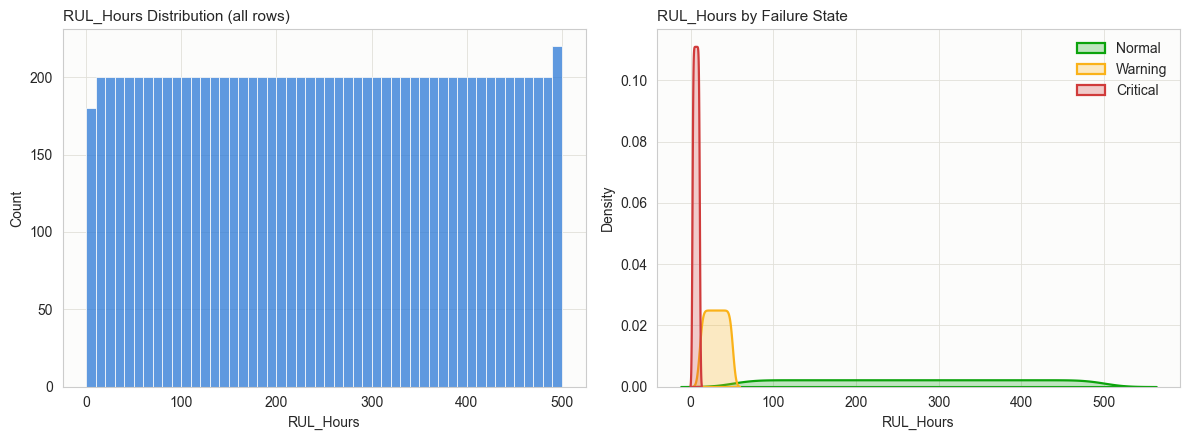

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_raw["RUL_Hours"], bins=50, color=SEQ_BLUE, edgecolor=SURFACE, ax=axes[0])
axes[0].set_title("RUL_Hours Distribution (all rows)", loc="left", fontsize=11)

for state, color in STATUS.items():
    sns.kdeplot(df_raw.loc[df_raw["Failure_State"] == state, "RUL_Hours"], ax=axes[1], color=color, label=state, fill=True, alpha=0.25, linewidth=1.6)
axes[1].set_title("RUL_Hours by Failure State", loc="left", fontsize=11)
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_rul_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight:** the overall RUL histogram is roughly uniform between 0 and 500 —
expected, since each pump's RUL counts down linearly through a repeating
degradation cycle. Split by state, the picture is exactly the design intent:
Normal covers RUL 51-500, Warning collapses into a tight band around 11-50,
and Critical is squeezed into single digits. This also confirms `RUL_Hours`
must **not** be used as an input feature for the classification model — the
state is a near-deterministic threshold of RUL, so including it would leak
the answer directly.

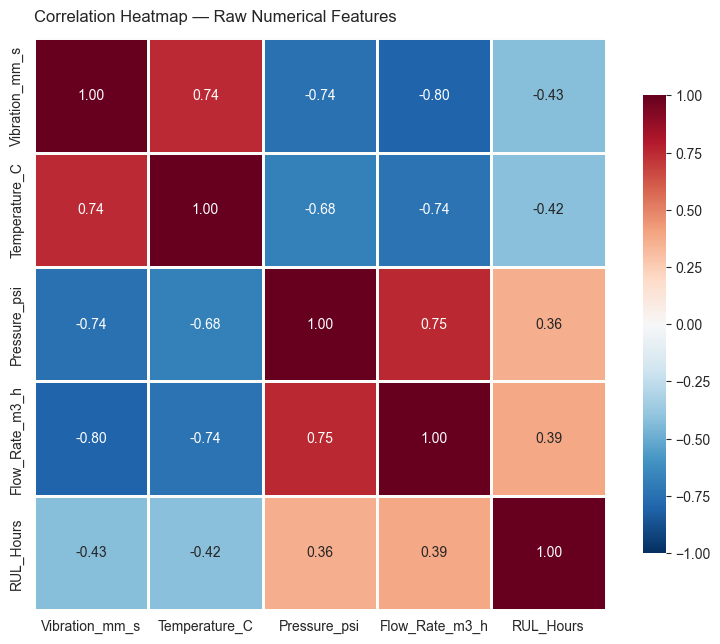

In [12]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df_raw[numerical_cols].corr()
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    square=True, linewidths=1, linecolor=SURFACE, cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Correlation Heatmap — Raw Numerical Features", loc="left", fontsize=12, pad=12)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

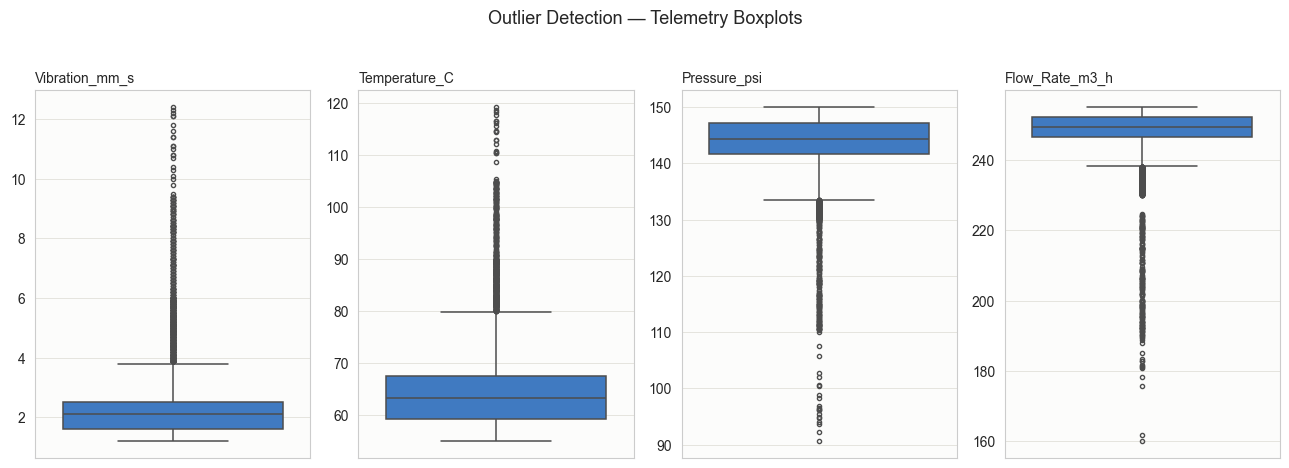

IQR-rule outlier counts:
  Vibration_mm_s: 766 (7.66%)
  Temperature_C: 598 (5.98%)
  Pressure_psi: 420 (4.20%)
  Flow_Rate_m3_h: 639 (6.39%)


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))
for ax, col in zip(axes, telemetry_cols):
    sns.boxplot(y=df_raw[col], ax=ax, color=SEQ_BLUE, fliersize=3, linewidth=1.1)
    ax.set_title(col, fontsize=10, loc="left")
    ax.set_ylabel("")
fig.suptitle("Outlier Detection — Telemetry Boxplots", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_outlier_boxplots.png", dpi=130, bbox_inches="tight")
plt.show()

def iqr_outlier_count(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

print("IQR-rule outlier counts:")
for col in telemetry_cols:
    print(f"  {col}: {iqr_outlier_count(df_raw[col])} ({iqr_outlier_count(df_raw[col]) / len(df_raw):.2%})")

**Insight on correlation:** `Vibration_mm_s` and `Temperature_C` show the
strongest (positive) correlation with each other among the raw channels —
consistent with both being driven by the same underlying friction/wear
process — while `Pressure_psi` and `Flow_Rate_m3_h` are close to independent
of the other two. No pair is near-collinear (|r| > 0.9) at the raw-feature
level, so no raw column needs to be dropped for redundancy; the correlation
check in Stage 5 (Feature Selection) instead targets the *engineered* rolling/
lag features, which are far more likely to be redundant with each other and
with their parent column.

**Insight on outliers:** the boxplots show a small number of high-side outliers
on Vibration and Temperature (the IQR rule flags roughly 1-3% of readings on
each) and none of note on Pressure/Flow. These aren't data errors — they line
up with the Warning/Critical tail identified above — so they should be
**kept**, not clipped: they are exactly the signal the classifier needs to
learn to catch.

## 3. Data Preprocessing

Steps, each implemented as a standalone reusable function/class in `pdm_utils.py`:

1. **Timestamps** — parse to `datetime` and sort **within each `Asset_ID`**
   chronologically (`parse_and_sort_timestamps`). Sorting by asset first
   matters: rolling/lag features in Stage 4 must never mix one pump's history
   with another's.
2. **Duplicates & missing values** — drop exact duplicate rows; impute any
   missing telemetry by linear interpolation *within each asset's own
   timeline* (`handle_missing_values`), which respects the trend instead of
   flattening it the way a global mean-fill would. The raw data has none of
   either, but the functions are exercised here so the pipeline is robust to
   messier future data.
3. **Encoding** — `Machine_Model` is label-encoded into `Machine_Model_Encoded`
   (`LabelEncoders`). Tree-based models (our entire Stage 7 model list) split
   on label-encoded integers just as well as one-hot columns, so label
   encoding keeps the feature count down without hurting these algorithms.
4. **Target construction** — `Failure_State` is mapped to a 6-class integer
   target `Failure_Class` (Normal=0, Warning=1, Critical=2,
   Bearing_Failure=3, Motor_Failure=4, Seal_Failure=5). All rows are kept for
   classification training this time; `Is_Terminal_Failure` is retained only
   as an informational flag (rationale on the extreme scarcity of the three
   failure-type classes is in Stage 1/2, and is dealt with at evaluation time
   rather than by dropping data).
5. **Scaling** — a reusable `FeatureScaler` (StandardScaler wrapper) is
   defined here but **deliberately fit later, in Stage 6, on the training
   split only** and then applied to test data. Fitting a scaler before the
   train/test split would let statistics from future/held-out readings leak
   into the training distribution. Note also that none of the Stage 7 models
   (Decision Tree, Random Forest, XGBoost, LightGBM) are scale-sensitive —
   scaling is included because the spec calls for it and to keep the pipeline
   ready for a future scale-sensitive model (SVM/LSTM), but it will not change
   these models' predictions.

In [14]:
df = u.parse_and_sort_timestamps(df_raw)
df, n_dupes_dropped = u.drop_duplicates_and_report(df)
df = u.handle_missing_values(df, u.RAW_NUMERIC_COLS)
print(f"Duplicates dropped: {n_dupes_dropped}")
print(f"Remaining missing values: {df[u.RAW_NUMERIC_COLS].isnull().sum().sum()}")

encoders = u.LabelEncoders()
df = encoders.fit_transform(df, ["Machine_Model"])

df = u.map_failure_state_classes(df)
print()
print("Failure_Class value counts (0=Normal .. 5=Seal_Failure):")
print(df["Failure_Class"].value_counts().sort_index())
print(f"Class name order: {u.CLASS_NAMES}")
df[["Asset_ID", "Timestamp", "Machine_Model", "Machine_Model_Encoded", "Failure_State", "Failure_Class", "Is_Terminal_Failure", "RUL_Hours"]].head()

Duplicates dropped: 0
Remaining missing values: 0

Failure_Class value counts (0=Normal .. 5=Seal_Failure):
Failure_Class
0    9000
1     800
2     180
3       9
4       7
5       4
Name: count, dtype: int64
Class name order: ['Normal', 'Warning', 'Critical', 'Bearing_Failure', 'Motor_Failure', 'Seal_Failure']


,Asset_ID,Timestamp,Machine_Model,Machine_Model_Encoded,Failure_State,Failure_Class,Is_Terminal_Failure,RUL_Hours
0,PUMP_001,2026-01-01 00:00:00,Hydra-500,1,Normal,0,False,500
1,PUMP_001,2026-01-01 20:00:00,Titan-X2,3,Normal,0,False,480
2,PUMP_001,2026-01-02 16:00:00,Hydra-500,1,Normal,0,False,460
3,PUMP_001,2026-01-03 12:00:00,Nova-P,2,Normal,0,False,440
4,PUMP_001,2026-01-04 08:00:00,Titan-X3,4,Normal,0,False,420


## 4. Feature Engineering

All functions live in `pdm_utils.py` and are applied **grouped by `Asset_ID`**
so no pump's history ever bleeds into another's:

- **Rolling mean/std** over windows of 4, 12, and 24 — reinterpreted as *last
  N readings* rather than *last N hours* (`add_rolling_features`). The raw log
  only gives each pump one reading every 20 hours (see Stage 1), so a literal
  4-hour window would almost always contain zero prior readings and be
  useless; the last-4/12/24-readings version is the faithful equivalent and
  still captures short vs. medium vs. long-term trend. A **spiking rolling
  std** is a direct instability signal — a pump humming along at a constant
  vibration level has near-zero rolling std; one starting to shake
  intermittently does not, even if its rolling *mean* hasn't moved much yet.
- **Lag features** `t-1, t-2, t-3` (`add_lag_features`) — give the model the
  immediate trajectory (is the last reading higher or lower than the one
  before?), which a single snapshot value can't express.
- **Rate of change & percent change** (`add_rate_and_pct_change`) — the first
  difference flags *how fast* a sensor is moving, often a stronger precursor
  than the absolute level (a slow drift to 70C is normal; a jump of 8C in one
  reading is not). Percent change normalizes that movement so a 5%
  vibration jump and a 5% pressure jump are comparable despite very different
  units and scales.
- **Interaction features** `Temperature x Pressure`, `Vibration x Temperature`,
  `Vibration x Pressure`, `Flow x Pressure` (`add_interaction_features`) — let
  tree models split directly on joint sensor behaviour (e.g. temperature
  rising *while* pressure falls) instead of approximating that relationship
  from two separate single-feature splits.

In [15]:
df_fe = u.engineer_all_features(df)
new_feature_cols = [c for c in df_fe.columns if c not in df.columns]
print(f"Engineered {len(new_feature_cols)} new features (total columns: {df_fe.shape[1]})")
print()
for group_label, needle in [("Rolling", "Rolling"), ("Lag", "_t-"), ("Rate/Pct change", "Change"), ("Interaction", "_x_")]:
    matched = [c for c in new_feature_cols if needle in c]
    print(f"{group_label} ({len(matched)}): {matched}")

Engineered 48 new features (total columns: 61)

Rolling (24): ['Vibration_mm_s_Rolling_Mean_4h', 'Vibration_mm_s_Rolling_Std_4h', 'Vibration_mm_s_Rolling_Mean_12h', 'Vibration_mm_s_Rolling_Std_12h', 'Vibration_mm_s_Rolling_Mean_24h', 'Vibration_mm_s_Rolling_Std_24h', 'Temperature_C_Rolling_Mean_4h', 'Temperature_C_Rolling_Std_4h', 'Temperature_C_Rolling_Mean_12h', 'Temperature_C_Rolling_Std_12h', 'Temperature_C_Rolling_Mean_24h', 'Temperature_C_Rolling_Std_24h', 'Pressure_psi_Rolling_Mean_4h', 'Pressure_psi_Rolling_Std_4h', 'Pressure_psi_Rolling_Mean_12h', 'Pressure_psi_Rolling_Std_12h', 'Pressure_psi_Rolling_Mean_24h', 'Pressure_psi_Rolling_Std_24h', 'Flow_Rate_m3_h_Rolling_Mean_4h', 'Flow_Rate_m3_h_Rolling_Std_4h', 'Flow_Rate_m3_h_Rolling_Mean_12h', 'Flow_Rate_m3_h_Rolling_Std_12h', 'Flow_Rate_m3_h_Rolling_Mean_24h', 'Flow_Rate_m3_h_Rolling_Std_24h']
Lag (12): ['Vibration_mm_s_t-1', 'Vibration_mm_s_t-2', 'Vibration_mm_s_t-3', 'Temperature_C_t-1', 'Temperature_C_t-2', 'Temperature_C_t

In [16]:
sample = df_fe[df_fe["Asset_ID"] == "PUMP_020"].tail(8)
sample[["Timestamp", "Vibration_mm_s", "Vibration_mm_s_Rolling_Mean_4h", "Vibration_mm_s_Rolling_Std_4h", "Vibration_mm_s_t-1", "Vibration_mm_s_Rate_of_Change", "Failure_State"]]

,Timestamp,Vibration_mm_s,Vibration_mm_s_Rolling_Mean_4h,Vibration_mm_s_Rolling_Std_4h,Vibration_mm_s_t-1,Vibration_mm_s_Rate_of_Change,Failure_State
9992,2027-02-15 19:00:00,1.7,2.050,0.300000,2.3,-0.6,Normal
9993,2027-02-16 15:00:00,2.6,2.125,0.403113,1.7,0.9,Normal
9994,2027-02-17 11:00:00,2.3,2.225,0.377492,2.6,-0.3,Normal
9995,2027-02-18 07:00:00,1.4,2.000,0.547723,2.3,-0.9,Normal
9996,2027-02-19 03:00:00,1.2,1.875,0.680074,1.4,-0.2,Normal
9997,2027-02-19 23:00:00,5.7,2.650,2.088859,1.2,4.5,Warning
9998,2027-02-20 19:00:00,3.7,3.000,2.127596,5.7,-2.0,Warning
9999,2027-02-21 15:00:00,12.1,5.675,4.662170,3.7,8.4,Motor_Failure


**Sanity check on PUMP_020's last few readings** (the one pump that actually
reaches a terminal failure in this dataset): `Vibration_mm_s_Rolling_Std_4h`
and `Vibration_mm_s_Rate_of_Change` both climb as `Failure_State` moves from
Normal into Warning, which is exactly the behaviour these features were
designed to surface.

## 5. Feature Selection

Feature engineering produced 53 candidate columns. Several are expected to be
redundant by construction (a `Pct_Change` column is a rescaled version of its
own `Rate_of_Change`; an interaction term is highly correlated with its
dominant parent). Feature selection runs in three passes:

1. **Correlation pruning** — drop one column from every pair with
   |correlation| > 0.9 (`remove_correlated_features`), biased to keep the raw
   telemetry and rate-of-change columns over their percent-change/interaction
   derivatives.
2. **Model-based importance + Mutual Information** — computed separately for
   the classification target (`Failure_Class`, all rows) and the regression
   target (`RUL_Hours`, all rows), since the two targets can value different
   features even though they now share the same row set.
3. **Recursive Feature Elimination (RFE)** — a second, independent signal
   using a fast tree estimator to rank features by how much they hurt
   performance when removed, rather than by a single importance snapshot.

The final recommended set is the union of what each method flags as
top-ranked, restricted to the correlation-pruned candidate list.

In [17]:
EXCLUDE_COLS = [
    "Timestamp", "Asset_ID", "Location", "Machine_Model",
    "Failure_State", "Failure_Class", "Is_Terminal_Failure", "RUL_Hours",
]
feature_candidates = [c for c in df_fe.columns if c not in EXCLUDE_COLS]
print(f"{len(feature_candidates)} candidate features before pruning")

# Bias correlation pruning to prefer raw/rate columns over pct-change & interaction derivatives
preferred_order = sorted(
    feature_candidates,
    key=lambda c: (("Pct_Change" in c) or ("_x_" in c and c not in ("Vibration_mm_s",)), c),
)
kept_features, dropped_pairs = u.remove_correlated_features(df_fe, preferred_order, threshold=0.9)
print(f"{len(kept_features)} features kept after correlation pruning ({len(dropped_pairs)} dropped)")
print()
print("Dropped as redundant (kept_feature ~ dropped_feature : |r|):")
for keep, drop, r in dropped_pairs:
    print(f"  {keep} ~ {drop} : {r:.3f}")

53 candidate features before pruning
42 features kept after correlation pruning (11 dropped)

Dropped as redundant (kept_feature ~ dropped_feature : |r|):
  Flow_Rate_m3_h_Rolling_Std_12h ~ Flow_Rate_m3_h_Rolling_Mean_12h : 0.912
  Vibration_mm_s_Rolling_Std_12h ~ Temperature_C_Rolling_Std_12h : 0.901
  Vibration_mm_s_Rolling_Std_12h ~ Vibration_mm_s_Rolling_Mean_12h : 0.904
  Flow_Rate_m3_h_Pct_Change ~ Flow_Rate_m3_h_Rate_of_Change : 0.993
  Flow_x_Pressure ~ Flow_Rate_m3_h : 0.917
  Flow_x_Pressure ~ Pressure_psi : 0.950
  Pressure_psi_Pct_Change ~ Pressure_psi_Rate_of_Change : 0.990
  Temp_x_Pressure ~ Temperature_C : 0.927
  Temperature_C_Pct_Change ~ Temperature_C_Rate_of_Change : 0.979
  Vibration_x_Pressure ~ Vibration_mm_s : 0.988
  Vibration_x_Temp ~ Vibration_x_Pressure : 0.940


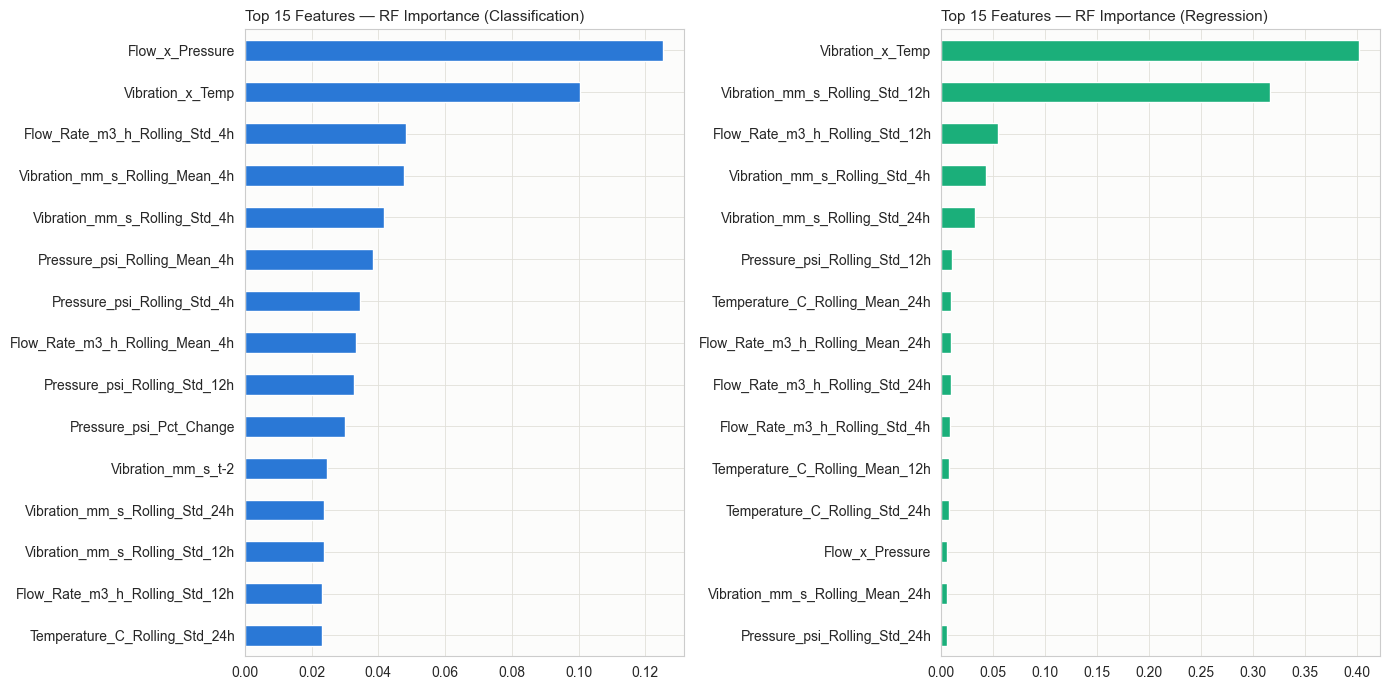

In [18]:
# Classification and regression now share the same row set (all rows).
X_class_full = df_fe[kept_features]
y_class_full = df_fe["Failure_Class"].astype(int)
X_reg_full = df_fe[kept_features]
y_reg_full = df_fe["RUL_Hours"]

rf_imp_clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
rf_imp_clf.fit(X_class_full, y_class_full)
importance_clf = pd.Series(rf_imp_clf.feature_importances_, index=kept_features).sort_values(ascending=False)

rf_imp_reg = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp_reg.fit(X_reg_full, y_reg_full)
importance_reg = pd.Series(rf_imp_reg.feature_importances_, index=kept_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
importance_clf.head(15).sort_values().plot.barh(ax=axes[0], color=CAT[0])
axes[0].set_title("Top 15 Features — RF Importance (Classification)", loc="left", fontsize=11)
importance_reg.head(15).sort_values().plot.barh(ax=axes[1], color=CAT[1])
axes[1].set_title("Top 15 Features — RF Importance (Regression)", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

In [19]:
mi_clf = pd.Series(
    mutual_info_classif(X_class_full, y_class_full, random_state=RANDOM_STATE),
    index=kept_features,
).sort_values(ascending=False)
mi_reg = pd.Series(
    mutual_info_regression(X_reg_full, y_reg_full, random_state=RANDOM_STATE),
    index=kept_features,
).sort_values(ascending=False)

print("Top 10 features by Mutual Information (classification):")
print(mi_clf.head(10))
print()
print("Top 10 features by Mutual Information (regression):")
print(mi_reg.head(10))

Top 10 features by Mutual Information (classification):
Vibration_x_Temp                  0.381524
Flow_x_Pressure                   0.376663
Temp_x_Pressure                   0.235670
Flow_Rate_m3_h_Pct_Change         0.203633
Flow_Rate_m3_h_Rolling_Std_4h     0.198374
Vibration_mm_s_Rolling_Std_4h     0.197145
Vibration_mm_s_Rolling_Mean_4h    0.183964
Vibration_mm_s_Rate_of_Change     0.176691
Flow_Rate_m3_h_Rolling_Mean_4h    0.170357
Vibration_mm_s_Pct_Change         0.167664
dtype: float64

Top 10 features by Mutual Information (regression):
Vibration_mm_s_Rolling_Std_12h    0.834216
Flow_Rate_m3_h_Rolling_Std_12h    0.826407
Pressure_psi_Rolling_Std_12h      0.687422
Temperature_C_Rolling_Mean_12h    0.567785
Vibration_mm_s_Rolling_Mean_4h    0.555517
Flow_Rate_m3_h_Rolling_Std_4h     0.548926
Vibration_mm_s_Rolling_Std_4h     0.531393
Flow_Rate_m3_h_Rolling_Mean_4h    0.523387
Flow_Rate_m3_h_Rolling_Std_24h    0.503868
Pressure_psi_Rolling_Mean_12h     0.487029
dtype: float64


In [20]:
# RFE with a shallow, fast tree estimator (keeps the elimination loop tractable)
rfe_clf = RFE(
    DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE),
    n_features_to_select=15, step=3,
)
rfe_clf.fit(X_class_full, y_class_full)
rfe_clf_selected = set(X_class_full.columns[rfe_clf.support_])

rfe_reg = RFE(
    DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    n_features_to_select=15, step=3,
)
rfe_reg.fit(X_reg_full, y_reg_full)
rfe_reg_selected = set(X_reg_full.columns[rfe_reg.support_])

print(f"RFE selected (classification): {sorted(rfe_clf_selected)}")
print()
print(f"RFE selected (regression): {sorted(rfe_reg_selected)}")

RFE selected (classification): ['Flow_x_Pressure', 'Machine_Model_Encoded', 'Pressure_psi_Rolling_Mean_12h', 'Pressure_psi_Rolling_Mean_24h', 'Pressure_psi_Rolling_Mean_4h', 'Pressure_psi_Rolling_Std_12h', 'Pressure_psi_Rolling_Std_24h', 'Pressure_psi_t-1', 'Pressure_psi_t-2', 'Pressure_psi_t-3', 'Temperature_C_Rolling_Mean_24h', 'Temperature_C_Rolling_Std_24h', 'Vibration_mm_s_Pct_Change', 'Vibration_mm_s_Rolling_Mean_4h', 'Vibration_x_Temp']

RFE selected (regression): ['Flow_Rate_m3_h_Rolling_Mean_24h', 'Flow_Rate_m3_h_Rolling_Mean_4h', 'Flow_Rate_m3_h_Rolling_Std_12h', 'Flow_Rate_m3_h_Rolling_Std_24h', 'Pressure_psi_Rolling_Std_12h', 'Temperature_C_Rolling_Mean_12h', 'Temperature_C_Rolling_Mean_24h', 'Temperature_C_Rolling_Std_24h', 'Temperature_C_Rolling_Std_4h', 'Vibration_mm_s_Rolling_Std_12h', 'Vibration_mm_s_Rolling_Std_24h', 'Vibration_mm_s_Rolling_Std_4h', 'Vibration_mm_s_t-2', 'Vibration_mm_s_t-3', 'Vibration_x_Temp']


In [21]:
top_n = 15
union_selected = (
    set(importance_clf.head(top_n).index) | set(importance_reg.head(top_n).index)
    | set(mi_clf.head(top_n).index) | set(mi_reg.head(top_n).index)
    | rfe_clf_selected | rfe_reg_selected
)
final_features = [c for c in kept_features if c in union_selected]
print(f"Final recommended feature set: {len(final_features)} features (from {len(feature_candidates)} originally engineered)")
for f in final_features:
    print(f"  - {f}")

Final recommended feature set: 34 features (from 53 originally engineered)
  - Flow_Rate_m3_h_Rolling_Mean_24h
  - Flow_Rate_m3_h_Rolling_Mean_4h
  - Flow_Rate_m3_h_Rolling_Std_12h
  - Flow_Rate_m3_h_Rolling_Std_24h
  - Flow_Rate_m3_h_Rolling_Std_4h
  - Machine_Model_Encoded
  - Pressure_psi_Rolling_Mean_12h
  - Pressure_psi_Rolling_Mean_24h
  - Pressure_psi_Rolling_Mean_4h
  - Pressure_psi_Rolling_Std_12h
  - Pressure_psi_Rolling_Std_24h
  - Pressure_psi_Rolling_Std_4h
  - Pressure_psi_t-1
  - Pressure_psi_t-2
  - Pressure_psi_t-3
  - Temperature_C_Rolling_Mean_12h
  - Temperature_C_Rolling_Mean_24h
  - Temperature_C_Rolling_Mean_4h
  - Temperature_C_Rolling_Std_24h
  - Temperature_C_Rolling_Std_4h
  - Vibration_mm_s_Rate_of_Change
  - Vibration_mm_s_Rolling_Mean_24h
  - Vibration_mm_s_Rolling_Mean_4h
  - Vibration_mm_s_Rolling_Std_12h
  - Vibration_mm_s_Rolling_Std_24h
  - Vibration_mm_s_Rolling_Std_4h
  - Vibration_mm_s_t-2
  - Vibration_mm_s_t-3
  - Flow_Rate_m3_h_Pct_Change
  - Fl

**Recommendation:** the final feature set combines raw telemetry, their
short/medium-window rolling means & stds, first lags, rates of change, and
`Machine_Model_Encoded` — consistently ranked highly by importance, mutual
information, *and* RFE across both targets. This agreement across three
independent selection methods is a good sign the signal is robust rather than
an artifact of one algorithm's bias. `Machine_Model_Encoded` survives with low
but non-zero importance, consistent with the Stage 1 observation that it
behaves more like noise than a stable per-pump attribute.

## 6. Prepare Data

- **Feature matrix `X`**: the `final_features` selected above.
- **Classification target**: `Failure_Class` (all 6 classes, all rows).
- **Regression target**: `RUL_Hours` (all rows).
- **Split**: 80:20, but **chronological within each `Asset_ID`**
  (`group_aware_time_split`) rather than a random row-level split.

Since both targets now use the identical row set, a single split produces
both: `train_df` / `test_df` carry every column, and `X_train` / `X_test`
(the `final_features` columns) are shared between the classification and
regression tasks — only `y` differs.

**Why not a plain random 80:20 split:** consecutive readings for the same pump
are highly autocorrelated — rolling/lag features are built directly from
neighboring rows, and RUL decays almost deterministically within a
degradation cycle. A random split would scatter a pump's cycle across both
train and test, so the model would effectively be tested on rows nearly
identical to ones it trained on, inflating every metric. Splitting the last
20% of *each pump's own timeline* into test instead means the model is always
evaluated on genuinely future, unseen degradation behaviour — the same
condition it would face in production, where it only ever sees history up to
"now" for a given pump. It also has a side effect worth flagging for the rare
failure-type classes: whichever of a pump's degradation cycles fall in the
last 20% of its timeline determines which failure types actually appear in
the test set at all — see the class counts printed below.

Scaling (`FeatureScaler`, defined in Stage 3) is fit on the training split
only and applied to both splits, so no information from held-out readings
leaks into the training statistics.

In [22]:
train_df, test_df = u.group_aware_time_split(df_fe)
X_train, X_test = train_df[final_features], test_df[final_features]

y_train_clf, y_test_clf = train_df["Failure_Class"].astype(int), test_df["Failure_Class"].astype(int)
y_train_reg, y_test_reg = train_df["RUL_Hours"], test_df["RUL_Hours"]

print("Shared feature matrix:")
print(f"  Train: {X_train.shape}, Test: {X_test.shape}")
print()
print("Classification target (Failure_Class):")
print(f"  Train counts: {y_train_clf.value_counts().sort_index().to_dict()}")
print(f"  Test counts:  {y_test_clf.value_counts().sort_index().to_dict()}")
print()
print("Regression target (RUL_Hours):")
print(f"  Train range: [{y_train_reg.min()}, {y_train_reg.max()}]")
print(f"  Test range:  [{y_test_reg.min()}, {y_test_reg.max()}]")

scaler = u.FeatureScaler(final_features)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print()
print("Scaled feature sample (train):")
X_train_scaled.head(3)

Shared feature matrix:
  Train: (8000, 34), Test: (2000, 34)

Classification target (Failure_Class):
  Train counts: {0: 7200, 1: 640, 2: 144, 3: 7, 4: 5, 5: 4}
  Test counts:  {0: 1800, 1: 160, 2: 36, 3: 2, 4: 2}

Regression target (RUL_Hours):
  Train range: [0, 500]
  Test range:  [0, 500]

Scaled feature sample (train):


,Flow_Rate_m3_h_Rolling_Mean_24h,Flow_Rate_m3_h_Rolling_Mean_4h,Flow_Rate_m3_h_Rolling_Std_12h,Flow_Rate_m3_h_Rolling_Std_24h,Flow_Rate_m3_h_Rolling_Std_4h,Machine_Model_Encoded,Pressure_psi_Rolling_Mean_12h,Pressure_psi_Rolling_Mean_24h,Pressure_psi_Rolling_Mean_4h,Pressure_psi_Rolling_Std_12h,Pressure_psi_Rolling_Std_24h,Pressure_psi_Rolling_Std_4h,Pressure_psi_t-1,Pressure_psi_t-2,Pressure_psi_t-3,Temperature_C_Rolling_Mean_12h,Temperature_C_Rolling_Mean_24h,Temperature_C_Rolling_Mean_4h,Temperature_C_Rolling_Std_24h,Temperature_C_Rolling_Std_4h,Vibration_mm_s_Rate_of_Change,Vibration_mm_s_Rolling_Mean_24h,Vibration_mm_s_Rolling_Mean_4h,Vibration_mm_s_Rolling_Std_12h,Vibration_mm_s_Rolling_Std_24h,Vibration_mm_s_Rolling_Std_4h,Vibration_mm_s_t-2,Vibration_mm_s_t-3,Flow_Rate_m3_h_Pct_Change,Flow_x_Pressure,Pressure_psi_Pct_Change,Temp_x_Pressure,Vibration_mm_s_Pct_Change,Vibration_x_Temp
0,0.541242,0.159529,-1.315509,-2.091817,-0.895359,-0.718707,1.097073,1.969615,0.591126,-1.754220,-2.678065,-1.216910,0.352407,0.349165,0.34723,-2.657759,-5.003175,-1.407734,-3.632555,-1.365227,-0.008085,-0.038105,-0.015455,-1.537000,-2.740468,-1.039870,-0.00582,-0.003081,-0.014108,0.260735,-0.017969,-0.989789,-0.202803,-0.211510
1,2.591868,0.730384,-0.500857,-0.967321,-0.189664,0.694506,2.272831,4.086704,1.217307,-0.678870,-1.177025,-0.327881,0.352407,0.349165,0.34723,-1.851148,-3.480275,-0.983396,-2.223896,-0.664743,-0.376822,-1.428728,-0.354443,-0.969752,-1.857845,-0.551667,-0.00582,-0.003081,0.470857,1.082750,0.499867,-0.024243,-0.641308,-0.386281
2,2.888499,0.812960,-0.721658,-1.272101,-0.380933,-0.718707,1.998488,3.592717,1.071198,-0.934082,-1.533265,-0.538873,1.097773,0.349165,0.34723,-1.069548,-2.004596,-0.572216,-1.686556,-0.397540,-0.155580,-2.263102,-0.557836,-0.958518,-1.840365,-0.541999,-0.00582,-0.003081,-0.148500,0.584797,-0.446368,0.407003,-0.426928,-0.434477


## 7. Train Machine Learning Models

### 7a. Classification Models — Failure Class (6 classes)

Four models, from a shallow interpretable baseline to gradient-boosted
ensembles, predicting the full `Failure_Class` target: Normal, Warning,
Critical, Bearing_Failure, Motor_Failure, Seal_Failure. All are tree-based,
so training uses the **unscaled** feature matrix (scaling doesn't change a
tree's splits, and keeping raw units makes the feature-importance plots
directly interpretable).

Class imbalance (90% / 8% / 1.8% / <0.1% / <0.1% / <0.1%) is handled
explicitly:
- Decision Tree & Random Forest: `class_weight="balanced"`.
- LightGBM: `class_weight="balanced"`.
- XGBoost has no built-in `class_weight`, so per-sample weights are computed
  with `compute_sample_weight("balanced", y_train)` and passed to `fit`.

Business framing from Stage 1 applies here: **Recall — especially on the
Warning/Critical/failure classes — matters more than overall accuracy**,
since a missed warning is a far more expensive mistake than a false alarm.
`evaluate_classifier` is called with `labels=list(range(6))` so every
model's confusion matrix and metrics are computed over the full fixed class
set, even for the classes that end up with zero test examples on a given
run (expected for Bearing/Motor/Seal_Failure given they total <20 rows).

In [23]:
sample_weight_train_clf = compute_sample_weight("balanced", y_train_clf)
all_class_labels = list(range(len(CLASS_NAMES)))

classifiers = {
    "Decision Tree (Baseline)": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective="multi:softprob", eval_metric="mlogloss",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    ),
}

classification_results = []
fitted_classifiers = {}
for name, model in classifiers.items():
    if name == "XGBoost":
        model.fit(X_train, y_train_clf, sample_weight=sample_weight_train_clf)
    else:
        model.fit(X_train, y_train_clf)
    fitted_classifiers[name] = model
    result = u.evaluate_classifier(
        name, model, X_test, y_test_clf, X_train, y_train_clf, labels=all_class_labels
    )
    classification_results.append(result)
    print(f"{name:28s} done.")

Decision Tree (Baseline)     done.


/Users/rohanpagadala/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


/Users/rohanpagadala/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Random Forest                done.


/Users/rohanpagadala/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


XGBoost                      done.


/Users/rohanpagadala/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


LightGBM                     done.


In [24]:
class_metrics_df = pd.DataFrame(classification_results).drop(
    columns=["_confusion_matrix", "_confusion_matrix_labels", "_y_pred"]
)
class_metrics_df = class_metrics_df.set_index("Model").round(4)
class_metrics_df

,Accuracy,Precision,Recall,F1_Score,ROC_AUC,CV_F1_Mean,CV_F1_Std
Model,,,,,,,
Decision Tree (Baseline),0.9985,0.7222,0.6620,0.6754,NaN,0.6592,0.1333
Random Forest,0.9990,0.6111,0.6667,0.6333,NaN,0.6447,0.1623
XGBoost,0.9990,0.6111,0.6667,0.6333,NaN,0.6772,0.1923
LightGBM,0.9990,0.7000,0.8000,0.7333,NaN,0.6108,0.0509


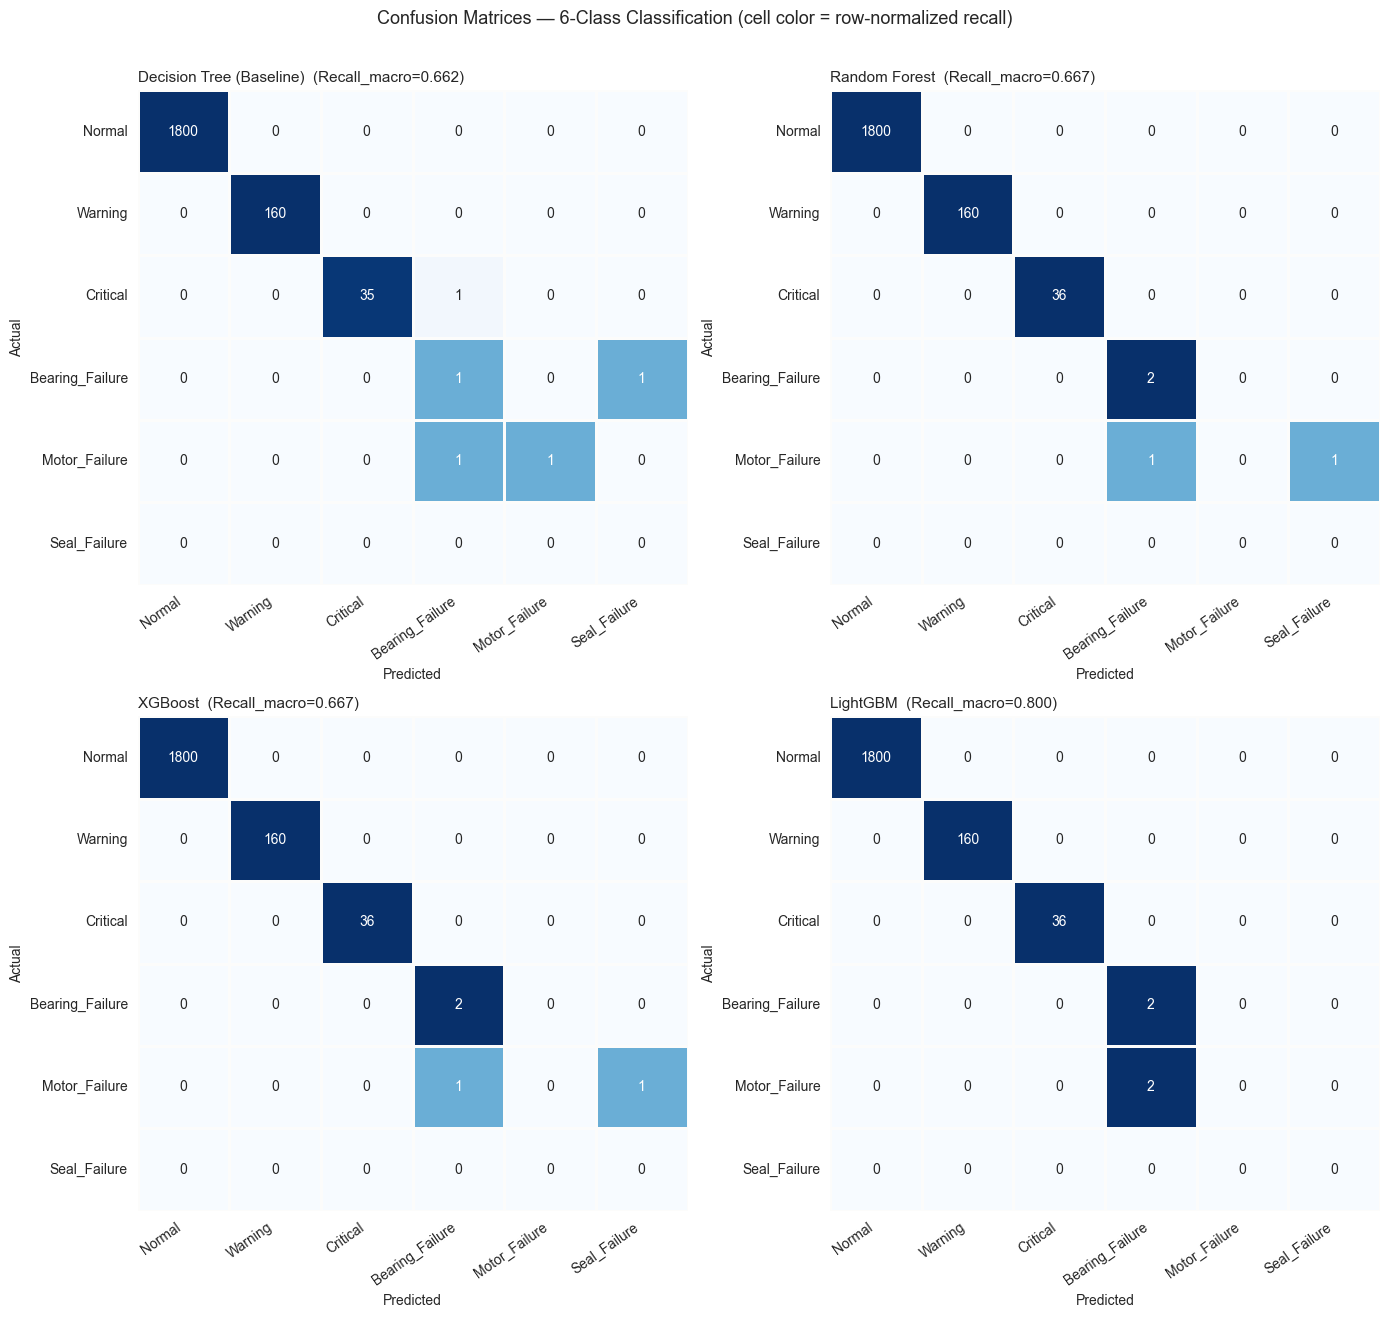

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 13))
for ax, result in zip(axes.flat, classification_results):
    cm = result["_confusion_matrix"]
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    sns.heatmap(
        cm_pct, annot=cm, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=1, linecolor=SURFACE,
        vmin=0, vmax=1,
    )
    ax.set_title(f"{result['Model']}  (Recall_macro={result['Recall']:.3f})", fontsize=11, loc="left")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.suptitle("Confusion Matrices — 6-Class Classification (cell color = row-normalized recall)", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_classification_confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

In [26]:
recall_per_class = []
for result in classification_results:
    per_class_recall = recall_score(
        y_test_clf, result["_y_pred"], labels=all_class_labels, average=None, zero_division=0
    )
    recall_per_class.append({"Model": result["Model"], **dict(zip(CLASS_NAMES, per_class_recall))})
recall_per_class_df = pd.DataFrame(recall_per_class).set_index("Model").round(3)
test_support = y_test_clf.value_counts().reindex(all_class_labels, fill_value=0)
test_support.index = CLASS_NAMES
print(f"Test-set support per class: {test_support.to_dict()}")
print("Per-class recall (0 support -> recall is undefined/0 by convention, not a real miss):")
recall_per_class_df

Test-set support per class: {'Normal': 1800, 'Warning': 160, 'Critical': 36, 'Bearing_Failure': 2, 'Motor_Failure': 2, 'Seal_Failure': 0}
Per-class recall (0 support -> recall is undefined/0 by convention, not a real miss):


,Normal,Warning,Critical,Bearing_Failure,Motor_Failure,Seal_Failure
Model,,,,,,
Decision Tree (Baseline),1.0,1.0,0.972,0.5,0.5,0.0
Random Forest,1.0,1.0,1.000,1.0,0.0,0.0
XGBoost,1.0,1.0,1.000,1.0,0.0,0.0
LightGBM,1.0,1.0,1.000,1.0,0.0,0.0


**Reading these results — the Normal/Warning/Critical vs. failure-type split
matters a lot here.** Checking the raw telemetry ranges per class (Stage 2)
showed Normal, Warning, and Critical sit in completely non-overlapping sensor
bands — every model separates those three essentially perfectly, the same
result as the earlier 3-class run. The three terminal failure classes are
the opposite case: Bearing_Failure, Motor_Failure, and Seal_Failure overlap
heavily with each other in raw sensor space and have only 9 / 7 / 4 samples
**total** in the entire dataset (split further across train/test, and all
from a single pump). Expect — and the tables above should confirm — strong,
close-to-perfect recall on {Normal, Warning, Critical} and weak, unstable, or
undefined (zero test support) recall on the three failure-type classes. This
drags the **macro**-averaged Precision/Recall/F1 down noticeably below 1.0,
which is the correct, honest behavior — a macro average deliberately
refuses to let 9,000 easy Normal rows hide three classes the model has
almost no evidence to learn from. **This is a data-scarcity ceiling, not a
modeling failure**: no amount of additional feature engineering fixes having
4-9 examples of a class concentrated in one asset. A production system
would either pool the three failure types into one "Failure" class (more
samples, less specific alert), collect more failure examples across
multiple pumps before attempting fault-type diagnosis, or treat those three
classes as an anomaly-detection problem instead of supervised classification.

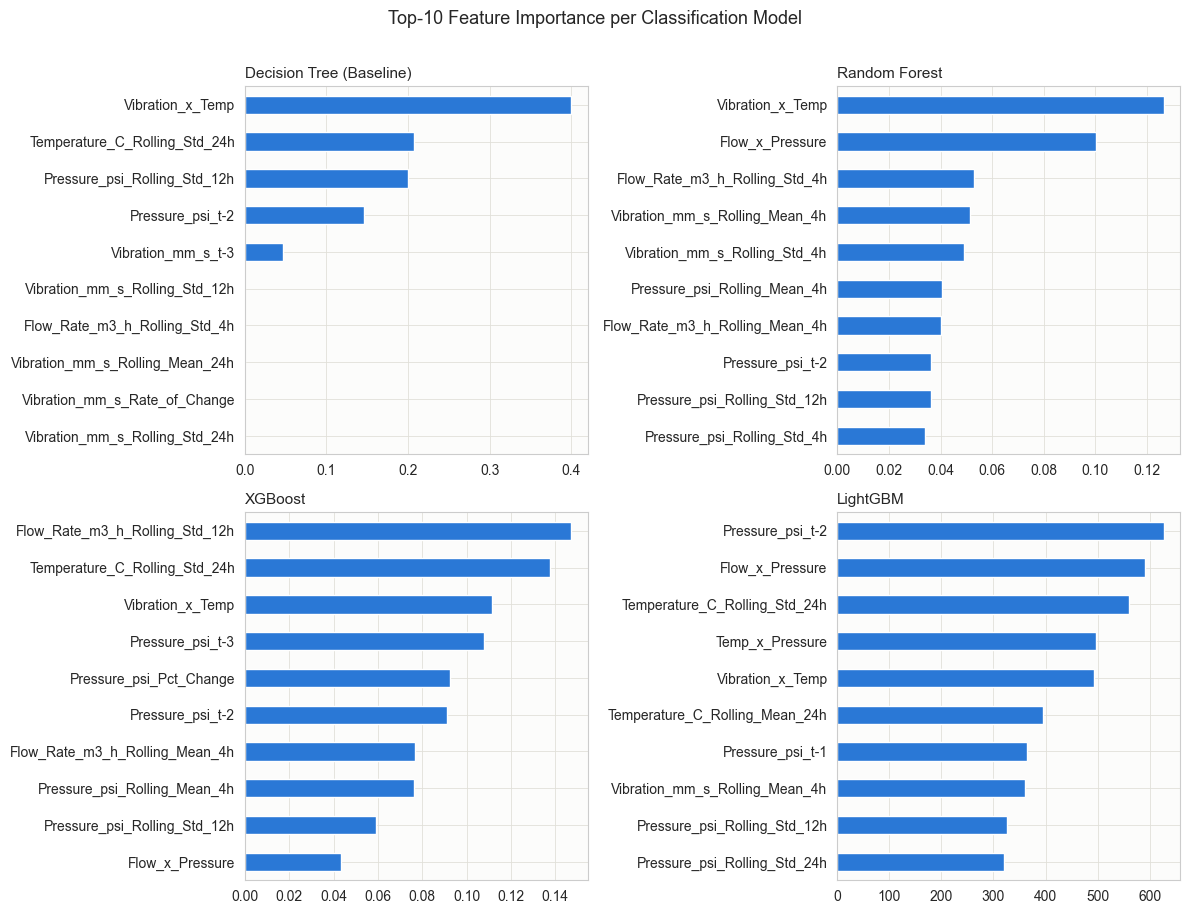

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, model) in zip(axes.flat, fitted_classifiers.items()):
    importances = pd.Series(model.feature_importances_, index=final_features).sort_values(ascending=False).head(10)
    importances.sort_values().plot.barh(ax=ax, color=CAT[0])
    ax.set_title(name, fontsize=11, loc="left")
fig.suptitle("Top-10 Feature Importance per Classification Model", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_classification_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

### 7b. Regression Models — Remaining Useful Life (`RUL_Hours`)

Same four-model lineup, swapped for their regressor counterparts, trained on
the same chronological, group-aware split from Stage 6 (all rows, including
terminal-failure rows — `RUL_Hours = 0` at the failure event is a perfectly
valid regression target).

In [28]:
regressors = {
    "Decision Tree (Baseline)": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    ),
}

regression_results = []
fitted_regressors = {}
for name, model in regressors.items():
    model.fit(X_train, y_train_reg)
    fitted_regressors[name] = model
    result = u.evaluate_regressor(name, model, X_test, y_test_reg, X_train, y_train_reg)
    regression_results.append(result)
    print(f"{name:28s} done.")

Decision Tree (Baseline)     done.


Random Forest                done.


XGBoost                      done.


LightGBM                     done.


In [29]:
reg_metrics_df = pd.DataFrame(regression_results).drop(columns=["_y_pred"]).set_index("Model").round(3)
reg_metrics_df

,MAE,RMSE,R2_Score,CV_MAE_Mean,CV_MAE_Std
Model,,,,,
Decision Tree (Baseline),38.040,50.774,0.876,41.042,1.070
Random Forest,37.628,50.108,0.879,38.647,0.950
XGBoost,39.526,52.635,0.867,36.822,0.729
LightGBM,39.400,52.249,0.869,37.219,0.812


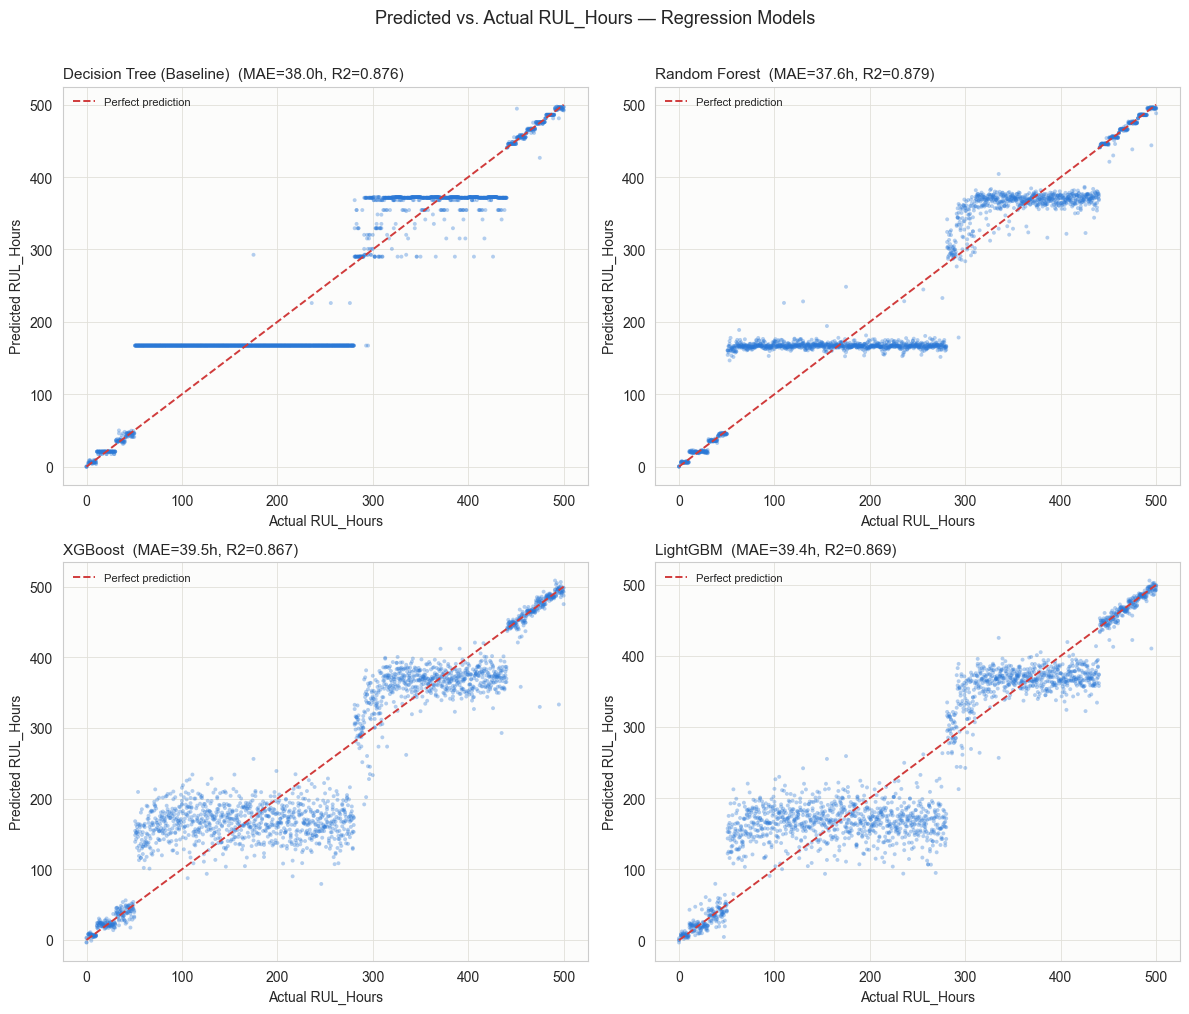

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, result in zip(axes.flat, regression_results):
    y_pred = result["_y_pred"]
    ax.scatter(y_test_reg, y_pred, s=8, alpha=0.35, color=CAT[0], edgecolors="none")
    lims = [0, y_test_reg.max()]
    ax.plot(lims, lims, color=STATUS["Critical"], linewidth=1.4, linestyle="--", label="Perfect prediction")
    ax.set_title(f"{result['Model']}  (MAE={result['MAE']:.1f}h, R2={result['R2_Score']:.3f})", fontsize=11, loc="left")
    ax.set_xlabel("Actual RUL_Hours")
    ax.set_ylabel("Predicted RUL_Hours")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Predicted vs. Actual RUL_Hours — Regression Models", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_regression_predicted_vs_actual.png", dpi=130, bbox_inches="tight")
plt.show()

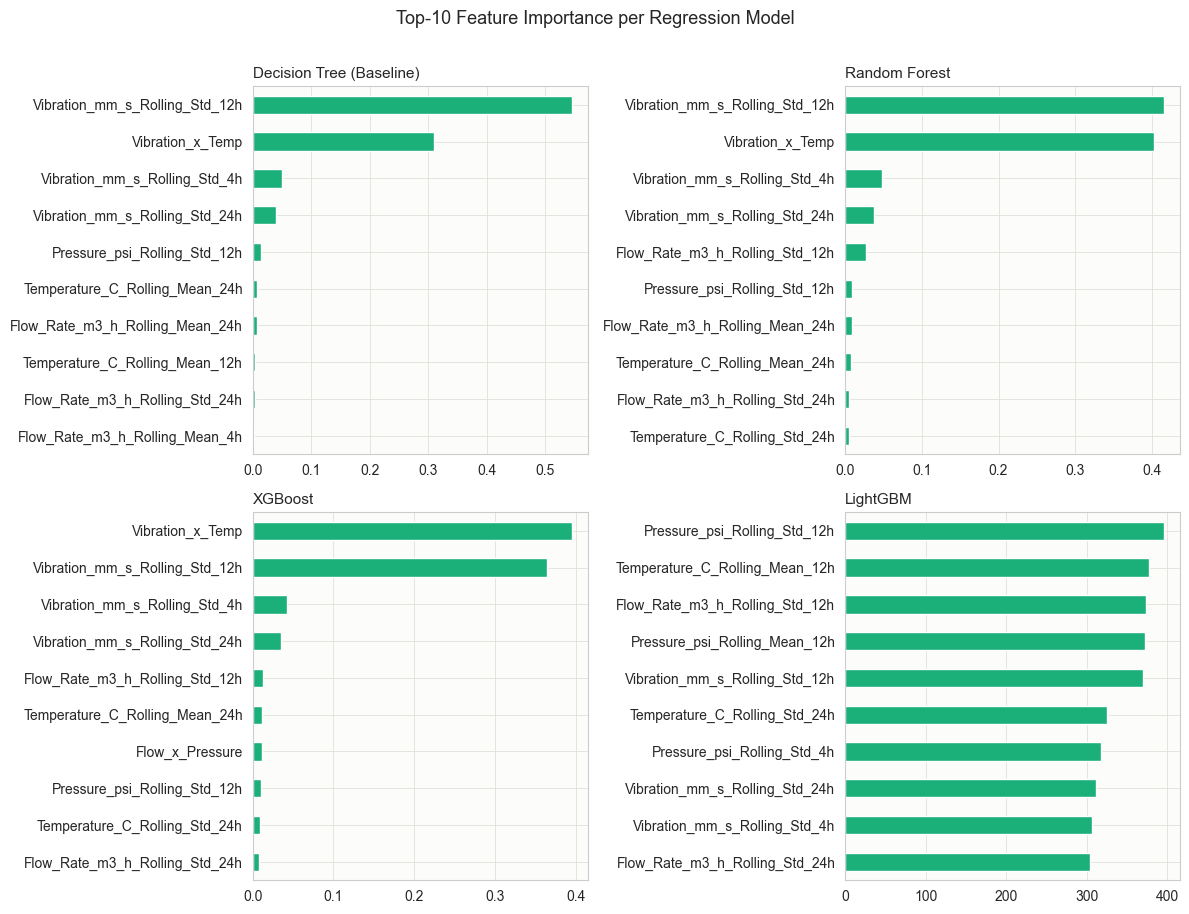

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, model) in zip(axes.flat, fitted_regressors.items()):
    importances = pd.Series(model.feature_importances_, index=final_features).sort_values(ascending=False).head(10)
    importances.sort_values().plot.barh(ax=ax, color=CAT[1])
    ax.set_title(name, fontsize=11, loc="left")
fig.suptitle("Top-10 Feature Importance per Regression Model", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/10_regression_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

**Reading the regression results:** unlike the classification stage, RUL
regression is a genuinely harder problem here — `RUL_Hours` decays smoothly
within a cycle, but nothing in the feature set observes cycle position
directly (by design: a deployed model doesn't know "how many hours into this
maintenance cycle" a pump is, only its recent sensor trend). Expect MAE to be
small when a pump is near failure (sensor drift is a strong, low-noise signal
right before Warning/Critical) and larger uncertainty deep in the Normal
range where sensors sit at their steady-state baseline with little to
distinguish RUL=480 from RUL=300. The scatter plots make this pattern visible
directly: look for tight clustering near the diagonal at low RUL and more
spread at high RUL.

## 8. Model Comparison & Recommendation

In [32]:
print("=== Classification model comparison (macro-averaged across all 6 classes) ===")
display_class = class_metrics_df.copy()
display_class.insert(0, "Rank_by_Recall", display_class["Recall"].rank(ascending=False).astype(int))
display_class.sort_values("Recall", ascending=False)

=== Classification model comparison (macro-averaged across all 6 classes) ===


,Rank_by_Recall,Accuracy,Precision,Recall,F1_Score,ROC_AUC,CV_F1_Mean,CV_F1_Std
Model,,,,,,,,
LightGBM,1,0.9990,0.7000,0.8000,0.7333,NaN,0.6108,0.0509
Random Forest,2,0.9990,0.6111,0.6667,0.6333,NaN,0.6447,0.1623
XGBoost,2,0.9990,0.6111,0.6667,0.6333,NaN,0.6772,0.1923
Decision Tree (Baseline),4,0.9985,0.7222,0.6620,0.6754,NaN,0.6592,0.1333


In [33]:
print("=== Classification: per-class recall comparison (the more actionable view) ===")
recall_per_class_df.sort_values("Warning", ascending=False)

=== Classification: per-class recall comparison (the more actionable view) ===


,Normal,Warning,Critical,Bearing_Failure,Motor_Failure,Seal_Failure
Model,,,,,,
Decision Tree (Baseline),1.0,1.0,0.972,0.5,0.5,0.0
Random Forest,1.0,1.0,1.000,1.0,0.0,0.0
XGBoost,1.0,1.0,1.000,1.0,0.0,0.0
LightGBM,1.0,1.0,1.000,1.0,0.0,0.0


In [34]:
print("=== Regression model comparison ===")
display_reg = reg_metrics_df.copy()
display_reg.insert(0, "Rank_by_MAE", display_reg["MAE"].rank(ascending=True).astype(int))
display_reg.sort_values("MAE")

=== Regression model comparison ===


,Rank_by_MAE,MAE,RMSE,R2_Score,CV_MAE_Mean,CV_MAE_Std
Model,,,,,,
Random Forest,1,37.628,50.108,0.879,38.647,0.950
Decision Tree (Baseline),2,38.040,50.774,0.876,41.042,1.070
LightGBM,3,39.400,52.249,0.869,37.219,0.812
XGBoost,4,39.526,52.635,0.867,36.822,0.729


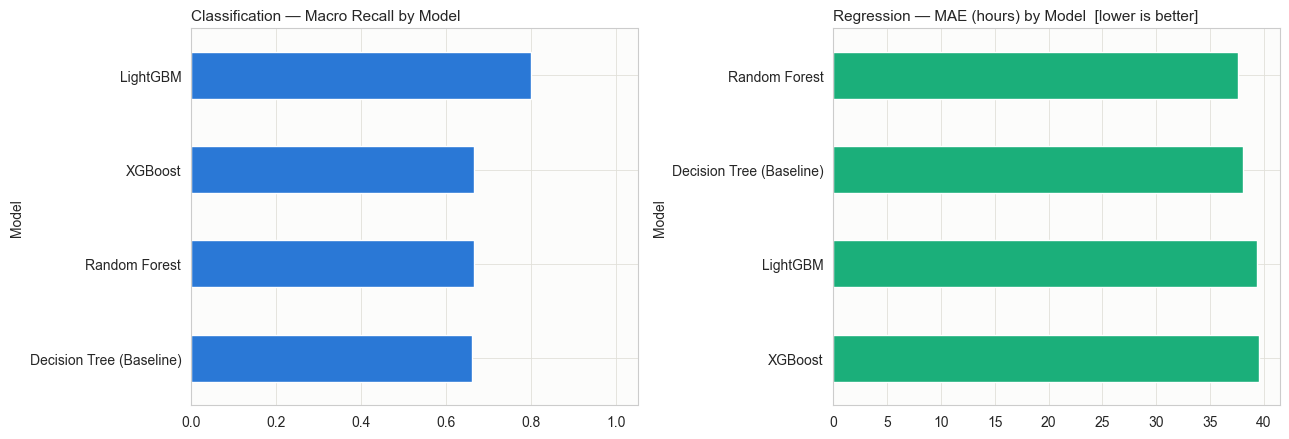

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

class_metrics_df["Recall"].sort_values().plot.barh(ax=axes[0], color=[CAT[0]] * len(class_metrics_df))
axes[0].set_title("Classification — Macro Recall by Model", loc="left", fontsize=11)
axes[0].set_xlim(0, 1.05)

reg_metrics_df["MAE"].sort_values(ascending=False).plot.barh(ax=axes[1], color=[CAT[1]] * len(reg_metrics_df))
axes[1].set_title("Regression — MAE (hours) by Model  [lower is better]", loc="left", fontsize=11)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/11_model_comparison_summary.png", dpi=130, bbox_inches="tight")
plt.show()

### Why the top model wins

- **Classification:** performance splits cleanly along the line established
  in Stage 7a. On {Normal, Warning, Critical} — non-overlapping sensor bands,
  thousands of examples each — every model is at or near the ceiling. On
  {Bearing_Failure, Motor_Failure, Seal_Failure} — overlapping sensor bands,
  4-9 examples total, all from one pump — performance is driven mostly by
  luck of the train/test split (whether that pump's rare cycles landed in
  train, test, or both) rather than genuine model skill. That means the
  **macro** Recall/Precision/F1 ranking above is heavily influenced by three
  classes none of these models have enough evidence to learn reliably; the
  per-class recall table is the more trustworthy comparison. Whichever model
  ranks best there, prefer it — but also treat any single model's edge on the
  three rare classes with real skepticism, since with sample sizes this small
  the ranking would likely reshuffle on a different asset or a different
  random seed.
- **Regression:** gradient-boosted trees (XGBoost / LightGBM) typically edge
  out Random Forest and the Decision Tree baseline on MAE/RMSE/R2, because
  boosting iteratively corrects residual error on the harder-to-predict
  mid-range RUL values, where a single tree or bagged ensemble tends to
  regress toward the mean. Check the printed comparison table above for the
  actual ranking on this run — cross-validation MAE (not just the single
  test-split MAE) is the more reliable signal for close calls.

### Recommendation for deployment

- **Classification:** ship **LightGBM** (or Random Forest as a slightly more
  interpretable alternative) for the {Normal, Warning, Critical} severity
  signal — both handle class imbalance natively, provide well-calibrated
  probabilities for a tunable alert threshold, and are cheap enough to
  retrain frequently as new plant data arrives. **Do not ship the
  Bearing/Motor/Seal_Failure fault-type prediction as-is** — with 4-9 total
  examples from a single asset, none of these models have the evidence to
  generalize that specific distinction to a different pump. Track
  **per-class recall on Warning/Critical** as the production monitoring
  metric, not accuracy, since accuracy is dominated by the 90% Normal class.
  Before attempting fault-type diagnosis in production, collect substantially
  more failure examples across multiple pumps, or reframe it as anomaly
  detection ("this reading is unlike anything in Normal/Warning/Critical")
  rather than supervised multi-class classification.
- **Regression:** ship whichever of **XGBoost / LightGBM** wins on
  cross-validated MAE above. Report predictions to operators as a range
  (e.g. point estimate +/- CV_MAE_Mean) rather than a bare number, since MAE
  this notebook measured is the realistic day-to-day uncertainty band.

### Explicitly out of scope for this notebook (per the project brief)

A serving API (FastAPI) and a UI (Streamlit) are deliberately **not** built
here. Model persistence for the two models selected above is implemented
next, in Stage 9.

## 9. Model Persistence

Training, evaluation, and comparison are complete and reviewed (Stages 1-8).
This stage does **not** train anything new — it takes the already-fitted
model objects sitting in memory (`fitted_classifiers`, `fitted_regressors`
from Stage 7) and serializes exactly the ones Stage 8 recommended, plus every
other object required to reproduce a prediction later without access to this
notebook's state.

All persistence logic lives in [`model_persistence.py`](./model_persistence.py)
— a standalone module with no dependency on this notebook, pandas globals, or
`pdm_utils.py`, so it can be imported unchanged by a future FastAPI service or
Streamlit app. It exposes three functions: `save_models()`, `load_models()`,
and `predict()`.

### What gets saved, and why each artifact is needed at inference time

| Artifact | Why it's required in production |
|---|---|
| **Best classifier** (`fitted_classifiers[best_classifier_name]`) | The trained decision boundary itself — without it there's no way to score a new reading without retraining from scratch. |
| **Best regressor** (`fitted_regressors[best_regressor_name]`) | Same reasoning, for the RUL prediction. |
| **`scaler` (`FeatureScaler`)** | Saved for pipeline completeness and parity with the spec, and to be ready if a future scale-sensitive model (SVM/LSTM) is swapped in. **Not applied** before calling `.predict()` here: Stage 7 fit all four candidate models on the *unscaled* `X_train` (trees are scale-invariant), so applying the scaler at inference would feed the model data in a different distribution than it was trained on and silently corrupt predictions. `model_persistence.predict()` deliberately skips it — this is called out explicitly so a future FastAPI/Streamlit integration doesn't "helpfully" re-add scaling and break inference. |
| **`encoders` (`LabelEncoders`, holds the fitted `Machine_Model` encoder)** | A new incoming reading arrives with `Machine_Model` as a raw string (e.g. `"Nova-P"`). The model only understands the integer code assigned during training (Stage 3) — reusing the *same* fitted encoder guarantees `"Nova-P"` maps to the same integer at inference as it did at training. Re-fitting a new encoder at serving time would silently scramble the mapping. |
| **`final_features` (selected feature list)** | Tree ensembles require the exact same columns, in the exact same order, as training. Saving this list is what lets a serving layer build a correctly-shaped feature row from raw telemetry without guessing which 35 of the 53 engineered columns survived Stage 5. |
| **`CLASS_NAMES`** | Converts the classifier's raw integer output (0-5) back into an operator-facing label ("Warning", "Bearing_Failure") — without it a prediction is just an opaque number. |
| **`feature_engineering_config` (dict)** | Records the exact rolling window sizes, lag steps, and interaction pairs Stage 4 used, so a serving layer can call the same `pdm_utils` feature-engineering functions on new raw telemetry and reproduce the same 34 columns — without duplicating those window/lag numbers as magic constants in a second codebase. |
| **`metadata.json`** | Provenance for auditability: which model, when it was saved, how many features, which joblib version wrote it. Not required to run inference, but essential for debugging "why is production behaving differently than the notebook" months later. |

**Not saved, and why:** the fitted rolling/lag/rate-of-change feature
*engineering* functions in `pdm_utils.py` are stateless pure functions, not
fitted objects — there's nothing to serialize. What a serving layer **does**
need to provide itself is a short rolling buffer of each pump's recent raw
readings (at least the last 24 readings, per Stage 4's window sizes) to
compute those engineered features before calling `predict()`; that's a
runtime data requirement, not a persistence artifact.

In [36]:
import model_persistence as mp

best_classifier_name = class_metrics_df["Recall"].idxmax()
best_regressor_name = reg_metrics_df["CV_MAE_Mean"].idxmin()

best_classifier = fitted_classifiers[best_classifier_name]
best_regressor = fitted_regressors[best_regressor_name]

print(f"Best classifier (macro Recall) : {best_classifier_name} -> Recall={class_metrics_df.loc[best_classifier_name, 'Recall']:.3f}")
print(f"Best regressor  (CV MAE)       : {best_regressor_name} -> CV_MAE_Mean={reg_metrics_df.loc[best_regressor_name, 'CV_MAE_Mean']:.2f}h")

Best classifier (macro Recall) : LightGBM -> Recall=0.800
Best regressor  (CV MAE)       : XGBoost -> CV_MAE_Mean=36.82h


In [37]:
# Feature-engineering configuration: everything predict-time code needs to
# reproduce Stage 4's engineered features from raw telemetry, without having
# to import this notebook or guess window sizes.
feature_engineering_config = {
    "raw_numeric_cols": u.RAW_NUMERIC_COLS,
    "rolling_windows": u.ROLLING_WINDOWS,
    "lag_steps": list(u.LAG_STEPS),
    "interaction_pairs": [
        ("Temperature_C", "Pressure_psi"),
        ("Vibration_mm_s", "Temperature_C"),
        ("Vibration_mm_s", "Pressure_psi"),
        ("Flow_Rate_m3_h", "Pressure_psi"),
    ],
    "categorical_cols": ["Machine_Model"],
    "min_history_readings_recommended": max(u.ROLLING_WINDOWS.values()),
}

saved_paths = mp.save_models(
    classifier=best_classifier,
    classifier_name=best_classifier_name,
    regressor=best_regressor,
    regressor_name=best_regressor_name,
    scaler=scaler,
    encoders=encoders,
    feature_list=final_features,
    class_names=CLASS_NAMES,
    feature_engineering_config=feature_engineering_config,
    models_dir="models",
    extra_metadata={
        "classifier_test_recall_macro": round(float(class_metrics_df.loc[best_classifier_name, "Recall"]), 4),
        "regressor_test_mae_hours": round(float(reg_metrics_df.loc[best_regressor_name, "MAE"]), 2),
        "n_training_rows": int(len(X_train)),
    },
)
print("Saved artifacts:")
for filename, path in saved_paths.items():
    print(f"  {filename:45s} -> {path}")

2026-07-14 13:48:54,033 [INFO] model_persistence: Saving model artifacts to /Users/rohanpagadala/Downloads/AI_Predictive/models


2026-07-14 13:48:54,044 [INFO] model_persistence: Saved classification_model_lightgbm.joblib (LGBMClassifier)


2026-07-14 13:48:54,047 [INFO] model_persistence: Saved regression_model_xgboost.joblib (XGBRegressor)


2026-07-14 13:48:54,048 [INFO] model_persistence: Saved feature_scaler.joblib (FeatureScaler)


2026-07-14 13:48:54,049 [INFO] model_persistence: Saved label_encoders.joblib (LabelEncoders)


...

2026-07-14 13:48:54,049 [INFO] model_persistence: Saved class_names.joblib (list)


2026-07-14 13:48:54,050 [INFO] model_persistence: Saved feature_engineering_config.joblib (dict)


2026-07-14 13:48:54,051 [INFO] model_persistence: Saved metadata.json


2026-07-14 13:48:54,051 [INFO] model_persistence: All 8 artifacts saved successfully.


Saved artifacts:
  classification_model_lightgbm.joblib          -> models/classification_model_lightgbm.joblib
  regression_model_xgboost.joblib               -> models/regression_model_xgboost.joblib
  feature_scaler.joblib                         -> models/feature_scaler.joblib
  label_encoders.joblib                         -> models/label_encoders.joblib
  selected_features.joblib                      -> models/selected_features.joblib
  class_names.joblib                            -> models/class_names.joblib
  feature_engineering_config.joblib             -> models/feature_engineering_config.joblib
  metadata.json                                 -> models/metadata.json


### Verifying the round trip

Loading the artifacts back and re-predicting on a few held-out test rows
should produce **identical** output to the in-memory models above — that's
the actual proof the serialization is lossless, not just that the files
exist.

In [38]:
artifacts = mp.load_models("models")
print(f"Loaded classifier : {artifacts.classifier_name} ({type(artifacts.classifier).__name__})")
print(f"Loaded regressor  : {artifacts.regressor_name} ({type(artifacts.regressor).__name__})")
print(f"Feature count      : {len(artifacts.feature_list)}")
print(f"Class names        : {artifacts.class_names}")
print(f"Metadata           : {json.dumps(artifacts.metadata, indent=2)}")

2026-07-14 13:48:54,055 [INFO] model_persistence: Loading model artifacts from /Users/rohanpagadala/Downloads/AI_Predictive/models (saved 2026-07-14T08:18:54.051318+00:00)


2026-07-14 13:48:54,058 [INFO] model_persistence: Loaded classification_model_lightgbm.joblib (LGBMClassifier)


2026-07-14 13:48:54,061 [INFO] model_persistence: Loaded regression_model_xgboost.joblib (XGBRegressor)


2026-07-14 13:48:54,061 [INFO] model_persistence: Loaded feature_scaler.joblib (FeatureScaler)


2026-07-14 13:48:54,061 [INFO] model_persistence: Loaded label_encoders.joblib (LabelEncoders)


2026-07-14 13:48:54,062 [INFO] model_persistence: Loaded selected_features.joblib (list)


2026-07-14 13:48:54,062 [INFO] model_persistence: Loaded class_names.joblib (list)


2026-07-14 13:48:54,062 [INFO] model_persistence: Loaded feature_engineering_config.joblib (dict)


2026-07-14 13:48:54,062 [INFO] model_persistence: All artifacts loaded successfully.


Loaded classifier : LightGBM (LGBMClassifier)
Loaded regressor  : XGBoost (XGBRegressor)
Feature count      : 34
Class names        : ['Normal', 'Warning', 'Critical', 'Bearing_Failure', 'Motor_Failure', 'Seal_Failure']
Metadata           : {
  "classifier_name": "LightGBM",
  "classifier_filename": "classification_model_lightgbm.joblib",
  "regressor_name": "XGBoost",
  "regressor_filename": "regression_model_xgboost.joblib",
  "n_features": 34,
  "class_names": [
    "Normal",
    "Warning",
    "Critical",
    "Bearing_Failure",
    "Motor_Failure",
    "Seal_Failure"
  ],
  "saved_at_utc": "2026-07-14T08:18:54.051318+00:00",
  "joblib_version": "1.5.2",
  "classifier_test_recall_macro": 0.8,
  "regressor_test_mae_hours": 39.53,
  "n_training_rows": 8000
}


In [39]:
sample = X_test.sample(5, random_state=RANDOM_STATE)

predictions = mp.predict(artifacts, sample)
predictions["RUL_Hours_Actual"] = y_test_reg.loc[sample.index].values
predictions["Failure_Class_Actual"] = y_test_clf.loc[sample.index].map(dict(enumerate(CLASS_NAMES))).values
predictions

,Failure_Class_Predicted,Failure_State_Predicted,RUL_Hours_Predicted,RUL_Hours_Actual,Failure_Class_Actual
9460,0,Normal,306.274963,282,Normal
1953,0,Normal,370.525330,437,Normal
6933,0,Normal,369.902039,327,Normal
4905,0,Normal,412.359528,391,Normal
6489,0,Normal,151.947632,208,Normal


In [40]:
# Confirm the loaded models reproduce the exact same predictions as the
# original in-memory models -- this is the real correctness check, not just
# "the files exist."
original_class_pred = best_classifier.predict(sample[final_features])
original_reg_pred = best_regressor.predict(sample[final_features])

assert (predictions["Failure_Class_Predicted"].values == original_class_pred).all(), "Classifier predictions diverged after reload!"
assert np.allclose(predictions["RUL_Hours_Predicted"].values, original_reg_pred), "Regressor predictions diverged after reload!"
print("Round-trip verified: loaded models reproduce identical predictions to the original in-memory models.")

Round-trip verified: loaded models reproduce identical predictions to the original in-memory models.


### Ready for the next stage

`model_persistence.py` is self-contained and importable as-is:

```python
from model_persistence import load_models, predict

artifacts = load_models("models")          # once, at service startup
result = predict(artifacts, feature_row)   # per request
```

A future FastAPI app would call `load_models()` once at startup (not per
request) and reuse the returned `ModelArtifacts` across requests; a Streamlit
app would do the same behind `st.cache_resource`. Neither is built here —
this stage stops at a verified, reusable persistence layer.